# Lesson 6A: Naive Bayes Theory

<a name="introduction"></a>
## Introduction

Suppose you want to classify an email as spam or not-spam based on the words it
contains, or a patient's diagnosis based on a set of symptoms. In both cases you
have a set of features and want to predict a class. Naive Bayes answers this with
a direct application of Bayes' theorem, combined with one simplifying assumption:
that the features are conditionally independent given the class.

That assumption is almost always false in the real world — the words in an email
are correlated, symptoms cluster together — yet Naive Bayes remains a strong
baseline on high-dimensional data, particularly text. Understanding why requires
separating what the model gets right (the decision boundary shape) from what it
gets wrong (the actual probability estimates).

What makes Naive Bayes distinctive:
1. **Generative model**: It models $P(\mathbf{x}, y)$ rather than $P(y \mid \mathbf{x})$ directly, so it can generate synthetic data and handles multi-class problems natively
2. **Closed-form training**: No iterative optimization — parameters are estimated directly via maximum likelihood
3. **Conditional independence**: Each feature contributes to the class probability independently of the others, given the class
4. **Robustness**: Even where the independence assumption is badly violated, the classifier's decisions often remain accurate

In this lesson, we'll:
1. Derive Bayes' theorem and the maximum a posteriori (MAP) decision rule
2. State the conditional independence assumption precisely and examine when it fails
3. Derive three variants: Gaussian, Multinomial, and Bernoulli Naive Bayes
4. Implement Gaussian Naive Bayes from scratch using maximum likelihood estimation
5. Compare the from-scratch implementation against scikit-learn
6. Analyze when the independence assumption holds and when it breaks

Lesson 6b applies Naive Bayes to text classification with TF-IDF and Laplace smoothing.


## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [Bayes' Theorem](#bayes-theorem)
   - [Derivation](#derivation)
   - [The MAP Decision Rule](#the-map-decision-rule)
4. [The Naive Bayes Classifier](#the-naive-bayes-classifier)
   - [Conditional Independence Assumption](#conditional-independence-assumption)
   - [A Worked Example](#a-worked-example)
   - [The Classification Rule](#the-classification-rule)
5. [Gaussian Naive Bayes](#gaussian-naive-bayes)
   - [Model Assumptions](#model-assumptions)
   - [Maximum Likelihood Estimation](#maximum-likelihood-estimation)
   - [Decision Boundary](#decision-boundary)
6. [Multinomial Naive Bayes](#multinomial-naive-bayes)
   - [Bag-of-Words Model](#bag-of-words-model)
   - [Parameter Estimation](#multinomial-parameter-estimation)
7. [Bernoulli Naive Bayes](#bernoulli-naive-bayes)
   - [Binary Feature Model](#binary-feature-model)
8. [The Zero-Frequency Problem](#the-zero-frequency-problem)
   - [Laplace Smoothing](#laplace-smoothing)
9. [From-Scratch Implementation](#from-scratch-implementation)
   - [Gaussian Naive Bayes in NumPy](#gaussian-naive-bayes-in-numpy)
10. [Visualization and Interpretation](#visualization-and-interpretation)
    - [Class-Conditional Densities](#class-conditional-densities)
    - [Decision Regions](#decision-regions)
11. [Practical Application](#practical-application)
    - [Multi-Class Classification on Wine Data](#multi-class-classification-on-wine-data)
    - [Comparison to Scikit-learn](#comparison-to-scikit-learn)
12. [When Independence Holds and When It Breaks](#when-independence-holds-and-when-it-breaks)
13. [Conclusion](#conclusion)
    - [Key Insights](#key-insights)
    - [When to Use Naive Bayes](#when-to-use-naive-bayes)
    - [Further Reading](#further-reading)


<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.naive_bayes import GaussianNB
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


<a name="bayes-theorem"></a>
## Bayes' Theorem

<a name="derivation"></a>
### Derivation

Bayes' theorem follows directly from the definition of conditional probability. For
events $A$ and $B$ with $P(B) > 0$:

$$P(A \mid B) = \frac{P(A, B)}{P(B)}$$

By symmetry of the joint probability, $P(A, B) = P(B \mid A) P(A)$, so substituting gives:

$$P(A \mid B) = \frac{P(B \mid A) P(A)}{P(B)}$$

For classification, let $y$ be the class label and $\mathbf{x} = (x_1, \ldots, x_d)$
be the feature vector. Bayes' theorem becomes:

$$P(y \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid y) P(y)}{P(\mathbf{x})}$$

Each term has a name:
- $P(y \mid \mathbf{x})$ — the **posterior**: probability of the class given the observed features
- $P(\mathbf{x} \mid y)$ — the **likelihood**: probability of observing these features given the class
- $P(y)$ — the **prior**: probability of the class before observing any features
- $P(\mathbf{x})$ — the **evidence**: total probability of observing these features, marginalized over all classes


In [2]:
print("\n" + "="*70)
print("BAYES' THEOREM")
print("="*70)
print("\n   P(y | x) = P(x | y) * P(y) / P(x)")
print("\n   posterior = likelihood * prior / evidence")
print("\n   - Posterior: what we want (class given features)")
print("   - Likelihood: model of the data generating process")
print("   - Prior: belief about class frequency before seeing features")
print("   - Evidence: normalizing constant, same for all classes")



BAYES' THEOREM

   P(y | x) = P(x | y) * P(y) / P(x)

   posterior = likelihood * prior / evidence

   - Posterior: what we want (class given features)
   - Likelihood: model of the data generating process
   - Prior: belief about class frequency before seeing features
   - Evidence: normalizing constant, same for all classes


<a name="the-map-decision-rule"></a>
### The MAP Decision Rule

The evidence $P(\mathbf{x})$ does not depend on $y$, so for classification we can
drop it and choose the class that maximizes the numerator. This is the **maximum a
posteriori (MAP)** decision rule:

$$\hat{y} = \arg\max_{y} P(y \mid \mathbf{x}) = \arg\max_{y} P(\mathbf{x} \mid y) P(y)$$

Taking logarithms (a monotonic transform, so it preserves the $\arg\max$) turns
products into sums, which is more numerically stable when $P(\mathbf{x} \mid y)$
involves many small probabilities multiplied together:

$$\hat{y} = \arg\max_{y} \left[ \log P(\mathbf{x} \mid y) + \log P(y) \right]$$


<a name="the-naive-bayes-classifier"></a>
## The Naive Bayes Classifier

<a name="conditional-independence-assumption"></a>
### Conditional Independence Assumption

Computing $P(\mathbf{x} \mid y)$ directly requires modeling the full joint
distribution of $d$ features, which needs exponentially many parameters as $d$
grows. Naive Bayes sidesteps this with the **conditional independence assumption**:
each feature is independent of every other feature, given the class:

$$P(\mathbf{x} \mid y) = P(x_1, x_2, \ldots, x_d \mid y) = \prod_{i=1}^{d} P(x_i \mid y)$$

This is "naive" because it is rarely true in practice — features are usually
correlated. But it reduces the number of parameters from exponential in $d$ to
linear in $d$, making the model tractable even with very high-dimensional data
such as text (tens of thousands of vocabulary words).

Combining the independence assumption with the MAP rule gives the full Naive
Bayes classification rule:

$$\hat{y} = \arg\max_{y} \left[ \log P(y) + \sum_{i=1}^{d} \log P(x_i \mid y) \right]$$


<a name="a-worked-example"></a>
### A Worked Example

Consider classifying a short message as spam or not-spam based on whether it
contains the words "free" and "meeting". Suppose from training data:

$$P(\text{spam}) = 0.4, \quad P(\text{free} \mid \text{spam}) = 0.8, \quad P(\text{meeting} \mid \text{spam}) = 0.1$$
$$P(\text{not-spam}) = 0.6, \quad P(\text{free} \mid \text{not-spam}) = 0.1, \quad P(\text{meeting} \mid \text{not-spam}) = 0.3$$

For a message containing both "free" and "meeting", conditional independence gives:

$$P(\text{free}, \text{meeting} \mid \text{spam}) = P(\text{free} \mid \text{spam}) \cdot P(\text{meeting} \mid \text{spam}) = 0.8 \times 0.1 = 0.08$$

This is an approximation — in reality, messages containing "free" may be more or
less likely to also contain "meeting" than the marginal rate would suggest.
Naive Bayes ignores that correlation entirely.


In [3]:
# Worked example: spam classification with two binary features
p_spam = 0.4
p_free_given_spam = 0.8
p_meeting_given_spam = 0.1

p_not_spam = 0.6
p_free_given_not_spam = 0.1
p_meeting_given_not_spam = 0.3

# Unnormalized posteriors (numerator of Bayes' theorem, using independence)
score_spam = p_spam * p_free_given_spam * p_meeting_given_spam
score_not_spam = p_not_spam * p_free_given_not_spam * p_meeting_given_not_spam

# Normalize to get actual posterior probabilities
evidence = score_spam + score_not_spam
posterior_spam = score_spam / evidence
posterior_not_spam = score_not_spam / evidence

print("\n" + "="*70)
print("WORKED EXAMPLE: SPAM CLASSIFICATION")
print("="*70)
print(f"\nUnnormalized score (spam):     {score_spam:.4f}")
print(f"Unnormalized score (not-spam): {score_not_spam:.4f}")
print(f"\nPosterior P(spam | free, meeting)     = {posterior_spam:.4f}")
print(f"Posterior P(not-spam | free, meeting) = {posterior_not_spam:.4f}")
print(f"\nMAP prediction: {'spam' if posterior_spam > posterior_not_spam else 'not-spam'}")



WORKED EXAMPLE: SPAM CLASSIFICATION

Unnormalized score (spam):     0.0320
Unnormalized score (not-spam): 0.0180

Posterior P(spam | free, meeting)     = 0.6400
Posterior P(not-spam | free, meeting) = 0.3600

MAP prediction: spam


<a name="the-classification-rule"></a>
### The Classification Rule

To summarize, Naive Bayes classification proceeds in two phases:

**Training**: Estimate $P(y)$ and $P(x_i \mid y)$ for every class $y$ and feature
$i$ from the training data.

**Prediction**: For a new point $\mathbf{x}$, compute the log-posterior score for
each class and pick the largest:

$$\hat{y} = \arg\max_{y} \left[ \log P(y) + \sum_{i=1}^{d} \log P(x_i \mid y) \right]$$

The three variants below differ only in how $P(x_i \mid y)$ is modeled.


<a name="gaussian-naive-bayes"></a>
## Gaussian Naive Bayes

<a name="model-assumptions"></a>
### Model Assumptions

Gaussian Naive Bayes assumes each continuous feature $x_i$, conditioned on class
$y$, follows a normal distribution:

$$P(x_i \mid y) = \frac{1}{\sqrt{2\pi\sigma_{i,y}^2}} \exp\left( -\frac{(x_i - \mu_{i,y})^2}{2\sigma_{i,y}^2} \right)$$

Each class has its own mean $\mu_{i,y}$ and variance $\sigma_{i,y}^2$ per feature —
so a problem with $d$ features and $K$ classes requires $2dK$ parameters for the
likelihoods, plus $K-1$ for the class priors.


<a name="maximum-likelihood-estimation"></a>
### Maximum Likelihood Estimation

Given training data $\{(\mathbf{x}_n, y_n)\}_{n=1}^{N}$, we estimate each class's
parameters using only the points belonging to that class. Let $N_y$ be the number
of training points with label $y$.

**Class prior** (relative frequency):

$$\hat{P}(y) = \frac{N_y}{N}$$

**Mean** (maximum likelihood estimate for a Gaussian is the sample mean):

$$\hat{\mu}_{i,y} = \frac{1}{N_y} \sum_{n: y_n = y} x_{n,i}$$

**Variance** (maximum likelihood estimate is the biased sample variance):

$$\hat{\sigma}_{i,y}^2 = \frac{1}{N_y} \sum_{n: y_n = y} (x_{n,i} - \hat{\mu}_{i,y})^2$$

**Derivation of the mean estimate.** The log-likelihood of the data for feature
$i$ and class $y$ under a Gaussian model is:

$$\ell(\mu_{i,y}, \sigma_{i,y}^2) = -\frac{N_y}{2} \log(2\pi\sigma_{i,y}^2) - \frac{1}{2\sigma_{i,y}^2} \sum_{n: y_n=y} (x_{n,i} - \mu_{i,y})^2$$

Setting the derivative with respect to $\mu_{i,y}$ to zero:

$$\frac{\partial \ell}{\partial \mu_{i,y}} = \frac{1}{\sigma_{i,y}^2} \sum_{n: y_n=y} (x_{n,i} - \mu_{i,y}) = 0 \quad \Rightarrow \quad \hat{\mu}_{i,y} = \frac{1}{N_y}\sum_{n: y_n=y} x_{n,i}$$

which is exactly the sample mean. A parallel derivation (setting
$\partial \ell / \partial \sigma_{i,y}^2 = 0$) recovers the sample variance formula above.
In practice, a small constant (variance smoothing, e.g. $10^{-9}$ times the largest
feature variance) is added to every $\hat{\sigma}_{i,y}^2$ to avoid division by zero
for near-constant features.


In [4]:
print("\n" + "="*70)
print("GAUSSIAN NAIVE BAYES: MLE PARAMETER ESTIMATION")
print("="*70)
print("\nFor each class y and feature i:")
print("   mu_hat[i,y]    = mean of feature i among training points with label y")
print("   sigma2_hat[i,y] = variance of feature i among training points with label y")
print("   P_hat(y)       = (count of label y) / (total training points)")
print("\nThese come directly from setting the derivative of the Gaussian")
print("log-likelihood to zero -- no iterative optimization required.")



GAUSSIAN NAIVE BAYES: MLE PARAMETER ESTIMATION

For each class y and feature i:
   mu_hat[i,y]    = mean of feature i among training points with label y
   sigma2_hat[i,y] = variance of feature i among training points with label y
   P_hat(y)       = (count of label y) / (total training points)

These come directly from setting the derivative of the Gaussian
log-likelihood to zero -- no iterative optimization required.


<a name="decision-boundary"></a>
### Decision Boundary

Substituting the Gaussian likelihood into the log-posterior score gives, for a
binary problem with equal variances across classes, a boundary that is linear in
$\mathbf{x}$. When variances differ between classes, the boundary becomes
quadratic — Gaussian Naive Bayes can carve out curved decision regions, unlike
plain linear classifiers such as logistic regression.


<a name="multinomial-naive-bayes"></a>
## Multinomial Naive Bayes

<a name="bag-of-words-model"></a>
### Bag-of-Words Model

For text data, features are typically word counts: $x_i$ is the number of times
word $i$ appears in a document. The multinomial distribution models the
probability of observing a particular count vector given the total word count
$n = \sum_i x_i$:

$$P(\mathbf{x} \mid y) = \frac{n!}{x_1! x_2! \cdots x_d!} \prod_{i=1}^{d} \theta_{i,y}^{x_i}$$

where $\theta_{i,y} = P(\text{word } i \mid y)$ is the probability of word $i$
appearing in a document of class $y$, with $\sum_i \theta_{i,y} = 1$.

Since the multinomial coefficient $\frac{n!}{x_1! \cdots x_d!}$ does not depend on
$y$, it cancels out of the $\arg\max$ and is dropped in practice:

$$\log P(\mathbf{x} \mid y) \propto \sum_{i=1}^{d} x_i \log \theta_{i,y}$$


<a name="multinomial-parameter-estimation"></a>
### Parameter Estimation

The maximum likelihood estimate of $\theta_{i,y}$ is the relative frequency of
word $i$ among all word occurrences in documents of class $y$:

$$\hat{\theta}_{i,y} = \frac{\sum_{n: y_n = y} x_{n,i}}{\sum_{j=1}^{d} \sum_{n: y_n = y} x_{n,j}}$$

the count of word $i$ in class $y$, divided by the total word count in class $y$.
This is the variant used for text classification (Lesson 6b covers this with
TF-IDF and Laplace smoothing in full).


<a name="bernoulli-naive-bayes"></a>
## Bernoulli Naive Bayes

<a name="binary-feature-model"></a>
### Binary Feature Model

Bernoulli Naive Bayes models each feature as a binary indicator — for text, this
is "does word $i$ appear in this document at all" rather than a count. Each
feature follows a Bernoulli distribution conditioned on class:

$$P(x_i \mid y) = p_{i,y}^{x_i} (1 - p_{i,y})^{1-x_i}, \qquad x_i \in \{0, 1\}$$

where $p_{i,y} = P(x_i = 1 \mid y)$. The maximum likelihood estimate is the
fraction of class-$y$ documents in which word $i$ appears at least once:

$$\hat{p}_{i,y} = \frac{\text{number of class-}y\text{ documents containing word }i}{N_y}$$

Unlike Multinomial NB, Bernoulli NB explicitly penalizes the *absence* of a word
via the $(1-p_{i,y})^{1-x_i}$ term. This matters for short documents where word
absence carries information (a spam filter cares whether "free" is absent from a
legitimate email, not just whether it is present in a spam one).


In [5]:
print("\n" + "="*70)
print("THREE NAIVE BAYES VARIANTS")
print("="*70)
print("\nGaussian NB:    continuous features, P(x_i|y) = Normal(mu_iy, sigma2_iy)")
print("Multinomial NB: count features (text), P(x|y) proportional to product theta_iy^x_i")
print("Bernoulli NB:   binary features, P(x_i|y) = p_iy^x_i * (1-p_iy)^(1-x_i)")
print("\nAll three share the same MAP decision rule and independence assumption;")
print("they differ only in the functional form of P(x_i | y).")



THREE NAIVE BAYES VARIANTS

Gaussian NB:    continuous features, P(x_i|y) = Normal(mu_iy, sigma2_iy)
Multinomial NB: count features (text), P(x|y) proportional to product theta_iy^x_i
Bernoulli NB:   binary features, P(x_i|y) = p_iy^x_i * (1-p_iy)^(1-x_i)

All three share the same MAP decision rule and independence assumption;
they differ only in the functional form of P(x_i | y).


<a name="the-zero-frequency-problem"></a>
## The Zero-Frequency Problem

<a name="laplace-smoothing"></a>
### Laplace Smoothing

For Multinomial and Bernoulli NB, if a word never appears in the training
documents of a class, its estimated probability is exactly zero. Since Naive
Bayes multiplies probabilities across features (or sums their logarithms), a
single zero-probability feature forces the entire class posterior to zero (or
$-\infty$ in log-space) regardless of how strongly the other features favor
that class.

**Laplace (additive) smoothing** fixes this by adding a pseudo-count $\alpha$
(typically $\alpha=1$) to every count before normalizing:

$$\hat{\theta}_{i,y} = \frac{\alpha + \sum_{n: y_n = y} x_{n,i}}{\alpha d + \sum_{j=1}^{d} \sum_{n: y_n = y} x_{n,j}}$$

The $\alpha d$ term in the denominator ensures $\sum_i \hat{\theta}_{i,y} = 1$
still holds. As $\alpha \to 0$, this recovers the unsmoothed MLE; as
$\alpha \to \infty$, all words become equally likely regardless of the data,
so $\alpha$ trades off between fitting the training counts and avoiding
zero-probability failures on unseen words. Lesson 6b explores this trade-off
directly on a text classification dataset.


<a name="from-scratch-implementation"></a>
## From-Scratch Implementation

<a name="gaussian-naive-bayes-in-numpy"></a>
### Gaussian Naive Bayes in NumPy

We implement Gaussian Naive Bayes directly from the MLE formulas derived above:
for each class, estimate the prior, per-feature mean, and per-feature variance,
then classify new points by the log-posterior score.


In [6]:
class GaussianNaiveBayes:
    """
    Gaussian Naive Bayes classifier using maximum likelihood parameter estimation.

    For each class y, estimates:
      - prior P(y) as the class relative frequency
      - per-feature mean mu[i, y] and variance sigma2[i, y]
    Classification uses the log-posterior score:
      score(y) = log P(y) + sum_i log Normal(x_i; mu[i,y], sigma2[i,y])
    """

    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing
        self.classes_ = None
        self.priors_ = None
        self.mean_ = None
        self.var_ = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)

        self.priors_ = np.zeros(n_classes)
        self.mean_ = np.zeros((n_classes, n_features))
        self.var_ = np.zeros((n_classes, n_features))

        # Variance smoothing constant, matching scikit-learn's convention:
        # a small fraction of the largest observed feature variance.
        epsilon = self.var_smoothing * X.var(axis=0).max()

        for idx, c in enumerate(self.classes_):
            X_c = X[y == c]
            self.priors_[idx] = X_c.shape[0] / n_samples
            self.mean_[idx, :] = X_c.mean(axis=0)
            self.var_[idx, :] = X_c.var(axis=0) + epsilon

        return self

    def _log_gaussian(self, X, mean, var):
        """Log-density of an independent Gaussian for each feature, summed."""
        # log N(x; mu, sigma^2) = -0.5*log(2*pi*sigma^2) - (x-mu)^2 / (2*sigma^2)
        log_prob = -0.5 * np.log(2 * np.pi * var) - ((X - mean) ** 2) / (2 * var)
        return log_prob.sum(axis=1)

    def _joint_log_likelihood(self, X):
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        joint_log_likelihood = np.zeros((n_samples, n_classes))

        for idx in range(n_classes):
            log_prior = np.log(self.priors_[idx])
            log_likelihood = self._log_gaussian(X, self.mean_[idx], self.var_[idx])
            joint_log_likelihood[:, idx] = log_prior + log_likelihood

        return joint_log_likelihood

    def predict(self, X):
        joint_log_likelihood = self._joint_log_likelihood(X)
        return self.classes_[np.argmax(joint_log_likelihood, axis=1)]

    def predict_proba(self, X):
        """Normalize joint log-likelihoods into posterior probabilities."""
        joint_log_likelihood = self._joint_log_likelihood(X)
        # Subtract max per row for numerical stability before exponentiating
        log_prob_norm = joint_log_likelihood - joint_log_likelihood.max(axis=1, keepdims=True)
        prob = np.exp(log_prob_norm)
        return prob / prob.sum(axis=1, keepdims=True)


print("\n" + "="*70)
print("GAUSSIAN NAIVE BAYES: FROM-SCRATCH IMPLEMENTATION")
print("="*70)
print("\nTraining: estimate prior, mean, and variance per class per feature")
print("Prediction: pick argmax over log P(y) + sum_i log N(x_i; mu_iy, sigma2_iy)")



GAUSSIAN NAIVE BAYES: FROM-SCRATCH IMPLEMENTATION

Training: estimate prior, mean, and variance per class per feature
Prediction: pick argmax over log P(y) + sum_i log N(x_i; mu_iy, sigma2_iy)


<a name="visualization-and-interpretation"></a>
## Visualization and Interpretation

<a name="class-conditional-densities"></a>
### Class-Conditional Densities

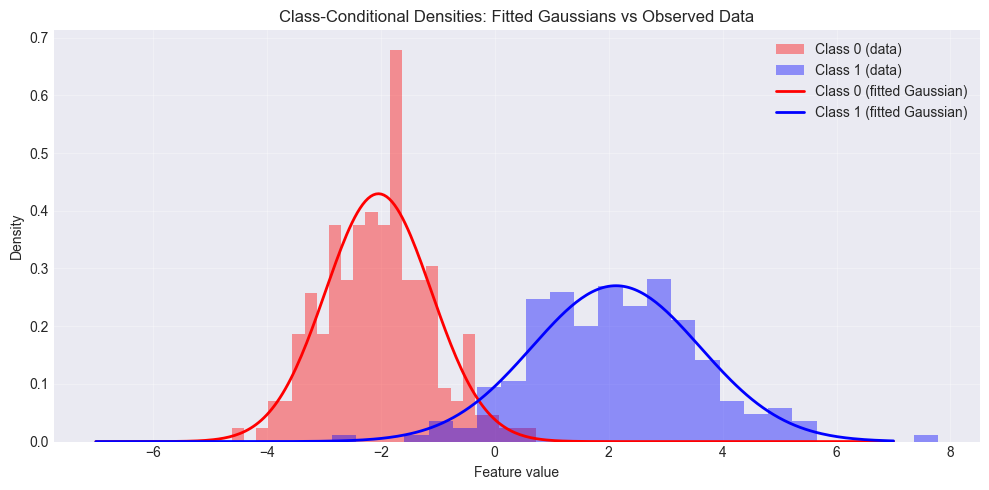


Class 0: mu_hat = -2.041, sigma_hat = 0.929
Class 1: mu_hat = 2.129, sigma_hat = 1.477

The fitted Gaussians closely track the empirical histograms, confirming
the MLE mean/variance estimates recover the true generating distributions.


In [7]:
# Visualize class-conditional Gaussian densities for a synthetic 1D feature
np.random.seed(42)
class0 = np.random.normal(loc=-2, scale=1.0, size=200)
class1 = np.random.normal(loc=2, scale=1.5, size=200)

X_1d = np.concatenate([class0, class1]).reshape(-1, 1)
y_1d = np.concatenate([np.zeros(200), np.ones(200)])

gnb_1d = GaussianNaiveBayes()
gnb_1d.fit(X_1d, y_1d)

x_range = np.linspace(-7, 7, 300).reshape(-1, 1)
log_lik_0 = gnb_1d._log_gaussian(x_range, gnb_1d.mean_[0], gnb_1d.var_[0])
log_lik_1 = gnb_1d._log_gaussian(x_range, gnb_1d.mean_[1], gnb_1d.var_[1])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(class0, bins=25, density=True, alpha=0.4, color='red', label='Class 0 (data)')
ax.hist(class1, bins=25, density=True, alpha=0.4, color='blue', label='Class 1 (data)')
ax.plot(x_range, np.exp(log_lik_0), 'r-', linewidth=2, label='Class 0 (fitted Gaussian)')
ax.plot(x_range, np.exp(log_lik_1), 'b-', linewidth=2, label='Class 1 (fitted Gaussian)')

ax.set_title('Class-Conditional Densities: Fitted Gaussians vs Observed Data')
ax.set_xlabel('Feature value')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nClass 0: mu_hat = {gnb_1d.mean_[0,0]:.3f}, sigma_hat = {np.sqrt(gnb_1d.var_[0,0]):.3f}")
print(f"Class 1: mu_hat = {gnb_1d.mean_[1,0]:.3f}, sigma_hat = {np.sqrt(gnb_1d.var_[1,0]):.3f}")
print("\nThe fitted Gaussians closely track the empirical histograms, confirming")
print("the MLE mean/variance estimates recover the true generating distributions.")


<a name="decision-regions"></a>
### Decision Regions

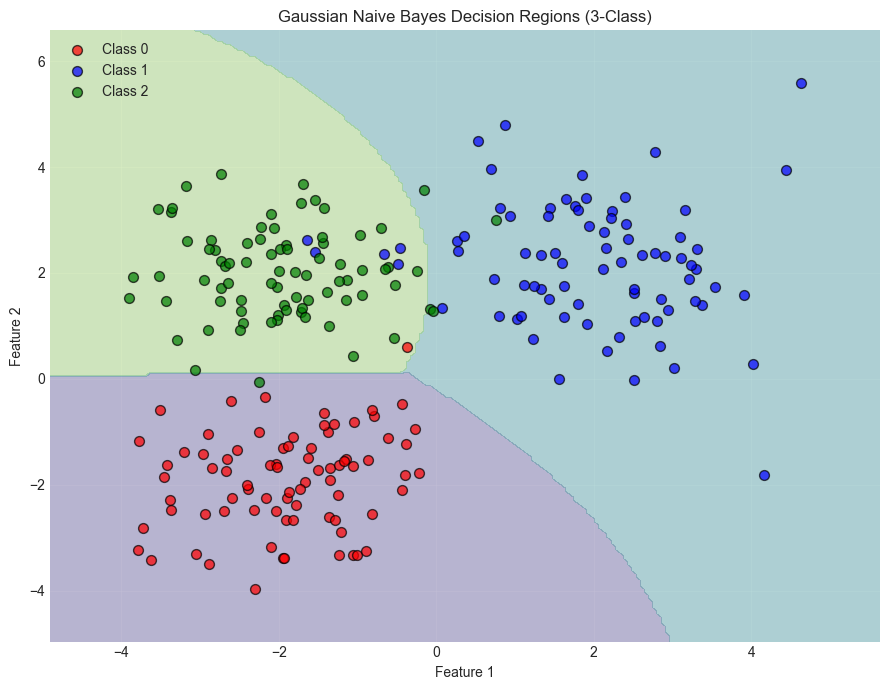


Training accuracy: 0.9542

Note the decision boundaries are curved, not straight lines -- each class
has a different covariance structure (though NB models features as
independent, so it only captures per-feature variance, not the true
correlation shown by the tilted point clouds above).


In [8]:
# Visualize 2D decision regions for Gaussian Naive Bayes
np.random.seed(42)
X_c0 = np.random.multivariate_normal([-2, -2], [[1.0, 0.3], [0.3, 1.0]], 80)
X_c1 = np.random.multivariate_normal([2, 2], [[1.5, -0.2], [-0.2, 1.5]], 80)
X_c2 = np.random.multivariate_normal([-2, 2], [[0.8, 0.0], [0.0, 0.8]], 80)

X_2d = np.vstack([X_c0, X_c1, X_c2])
y_2d = np.concatenate([np.zeros(80), np.ones(80), np.full(80, 2)])

gnb_2d = GaussianNaiveBayes()
gnb_2d.fit(X_2d, y_2d)

x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = gnb_2d.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(1, 1, figsize=(9, 7))
ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis', levels=[-0.5, 0.5, 1.5, 2.5])
colors = ['red', 'blue', 'green']
for c in range(3):
    ax.scatter(X_2d[y_2d == c, 0], X_2d[y_2d == c, 1], c=colors[c], label=f'Class {c}',
               s=50, edgecolors='k', alpha=0.7)

ax.set_title('Gaussian Naive Bayes Decision Regions (3-Class)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

train_acc = accuracy_score(y_2d, gnb_2d.predict(X_2d))
print(f"\nTraining accuracy: {train_acc:.4f}")
print("\nNote the decision boundaries are curved, not straight lines -- each class")
print("has a different covariance structure (though NB models features as")
print("independent, so it only captures per-feature variance, not the true")
print("correlation shown by the tilted point clouds above).")


<a name="practical-application"></a>
## Practical Application

<a name="multi-class-classification-on-wine-data"></a>
### Multi-Class Classification on Wine Data

In [9]:
# Load the wine dataset: 3 classes, 13 continuous chemical features
data = load_wine()
X_wine = data.data
y_wine = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

print("\n" + "="*70)
print("WINE DATASET")
print("="*70)
print(f"\nTotal samples: {X_wine.shape[0]}")
print(f"Features: {X_wine.shape[1]}")
print(f"Classes: {len(np.unique(y_wine))} ({data.target_names})")
print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")



WINE DATASET

Total samples: 178
Features: 13
Classes: 3 (['class_0' 'class_1' 'class_2'])

Training set: 142 samples
Test set: 36 samples


In [10]:
# Train from-scratch Gaussian Naive Bayes
gnb_scratch = GaussianNaiveBayes()
gnb_scratch.fit(X_train, y_train)

y_pred_train = gnb_scratch.predict(X_train)
y_pred_test = gnb_scratch.predict(X_test)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print("\n" + "="*70)
print("FROM-SCRATCH GAUSSIAN NAIVE BAYES RESULTS")
print("="*70)
print(f"\nTraining accuracy: {train_accuracy:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"\nConfusion Matrix (Test Set):")
print(confusion_matrix(y_test, y_pred_test))
print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=data.target_names))



FROM-SCRATCH GAUSSIAN NAIVE BAYES RESULTS

Training accuracy: 0.9789
Test accuracy: 0.9722

Confusion Matrix (Test Set):
[[12  0  0]
 [ 1 13  0]
 [ 0  0 10]]

Classification Report (Test Set):
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



<a name="comparison-to-scikit-learn"></a>
### Comparison to Scikit-learn

In [11]:
# Compare the from-scratch implementation to scikit-learn's GaussianNB
sklearn_gnb = GaussianNB()
sklearn_gnb.fit(X_train, y_train)

y_pred_sklearn_train = sklearn_gnb.predict(X_train)
y_pred_sklearn_test = sklearn_gnb.predict(X_test)

sklearn_train_acc = accuracy_score(y_train, y_pred_sklearn_train)
sklearn_test_acc = accuracy_score(y_test, y_pred_sklearn_test)

print("\n" + "="*70)
print("FROM-SCRATCH vs SCIKIT-LEARN GAUSSIANNB")
print("="*70)
print(f"\n{'Model':<28}{'Train Accuracy':<18}{'Test Accuracy':<18}")
print("-"*70)
print(f"{'From-scratch GaussianNB':<28}{train_accuracy:<18.4f}{test_accuracy:<18.4f}")
print(f"{'scikit-learn GaussianNB':<28}{sklearn_train_acc:<18.4f}{sklearn_test_acc:<18.4f}")

agreement = np.mean(y_pred_test == y_pred_sklearn_test)
print(f"\nAgreement between predictions (test set): {agreement:.4f}")

max_mean_diff = np.abs(gnb_scratch.mean_ - sklearn_gnb.theta_).max()
max_var_diff = np.abs(gnb_scratch.var_ - sklearn_gnb.var_).max()
print(f"\nMax difference in fitted means:     {max_mean_diff:.2e}")
print(f"Max difference in fitted variances: {max_var_diff:.2e}")
print("\nBoth implementations compute the same closed-form MLE estimates, so")
print("parameters match to within floating-point precision -- unlike SVM, there")
print("is no optimizer to introduce discrepancies.")



FROM-SCRATCH vs SCIKIT-LEARN GAUSSIANNB

Model                       Train Accuracy    Test Accuracy     
----------------------------------------------------------------------
From-scratch GaussianNB     0.9789            0.9722            
scikit-learn GaussianNB     0.9789            0.9722            

Agreement between predictions (test set): 1.0000

Max difference in fitted means:     0.00e+00
Max difference in fitted variances: 0.00e+00

Both implementations compute the same closed-form MLE estimates, so
parameters match to within floating-point precision -- unlike SVM, there
is no optimizer to introduce discrepancies.


<a name="when-independence-holds-and-when-it-breaks"></a>
## When Independence Holds and When It Breaks

The conditional independence assumption states $P(x_i, x_j \mid y) = P(x_i \mid y) P(x_j \mid y)$
for every pair of features $i \neq j$. We can measure how badly this is violated
by comparing the actual per-class covariance to a diagonal (independence-implying)
covariance.


In [12]:
# Measure how strongly features are correlated within each class
# (a violation of the conditional independence assumption)
print("\n" + "="*70)
print("TESTING THE CONDITIONAL INDEPENDENCE ASSUMPTION")
print("="*70)

for c in range(3):
    X_c = X_train[y_train == c]
    corr_matrix = np.corrcoef(X_c, rowvar=False)
    # Off-diagonal correlations; independence would make these all ~0
    off_diag = corr_matrix[~np.eye(corr_matrix.shape[0], dtype=bool)]
    mean_abs_corr = np.mean(np.abs(off_diag))
    max_abs_corr = np.max(np.abs(off_diag))
    print(f"\nClass {c} ({data.target_names[c]}):")
    print(f"  Mean |correlation| between feature pairs: {mean_abs_corr:.4f}")
    print(f"  Max |correlation| between feature pairs:  {max_abs_corr:.4f}")

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
print("\nIf conditional independence held exactly, all off-diagonal correlations")
print("would be zero. They are not -- chemical properties of wine (e.g. alcohol")
print("content and color intensity) are genuinely correlated within each class.")
print("\nYet Naive Bayes still classified test wines with high accuracy above.")
print("This is the central paradox of Naive Bayes: the model's PROBABILITY")
print("ESTIMATES are distorted by ignored correlations, but its final")
print("classification decision (the argmax over classes) is often still")
print("correct, because the distortion affects all classes in a similar way")
print("and the argmax only needs the RANKING of classes to be right, not the")
print("exact probability values.")



TESTING THE CONDITIONAL INDEPENDENCE ASSUMPTION

Class 0 (class_0):
  Mean |correlation| between feature pairs: 0.2252
  Max |correlation| between feature pairs:  0.7815

Class 1 (class_1):
  Mean |correlation| between feature pairs: 0.1788
  Max |correlation| between feature pairs:  0.7841

Class 2 (class_2):
  Mean |correlation| between feature pairs: 0.2339
  Max |correlation| between feature pairs:  0.7771

INTERPRETATION

If conditional independence held exactly, all off-diagonal correlations
would be zero. They are not -- chemical properties of wine (e.g. alcohol
content and color intensity) are genuinely correlated within each class.

Yet Naive Bayes still classified test wines with high accuracy above.
This is the central paradox of Naive Bayes: the model's PROBABILITY
ESTIMATES are distorted by ignored correlations, but its final
classification decision (the argmax over classes) is often still
correct, because the distortion affects all classes in a similar way
and the argmax

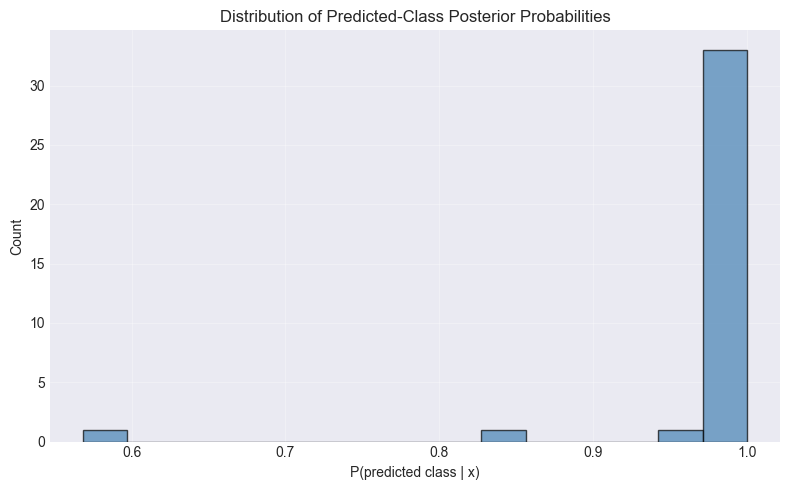


Fraction of test predictions with posterior > 0.99: 91.67%

Naive Bayes posteriors are frequently pushed toward 0 or 1 (overconfident)
when correlated features are treated as independent -- each correlated
feature's evidence gets double-counted in the log-posterior sum. The
classification (argmax) survives this distortion far better than the
probability calibration does.


In [13]:
# Demonstrate the ranking-vs-calibration distinction directly:
# compare predicted probabilities to true frequencies in bins
probs = gnb_scratch.predict_proba(X_test)
predicted_class_probs = probs[np.arange(len(y_test)), y_pred_test]

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.hist(predicted_class_probs, bins=15, color='steelblue', edgecolor='k', alpha=0.7)
ax.set_title('Distribution of Predicted-Class Posterior Probabilities')
ax.set_xlabel('P(predicted class | x)')
ax.set_ylabel('Count')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

overconfident_fraction = np.mean(predicted_class_probs > 0.99)
print(f"\nFraction of test predictions with posterior > 0.99: {overconfident_fraction:.2%}")
print("\nNaive Bayes posteriors are frequently pushed toward 0 or 1 (overconfident)")
print("when correlated features are treated as independent -- each correlated")
print("feature's evidence gets double-counted in the log-posterior sum. The")
print("classification (argmax) survives this distortion far better than the")
print("probability calibration does.")


<a name="conclusion"></a>
## Conclusion

<a name="key-insights"></a>
### Key Insights

1. **Bayes' theorem** provides a principled way to invert a generative model
   $P(\mathbf{x} \mid y)$ into the discriminative quantity we actually want, $P(y \mid \mathbf{x})$

2. **Conditional independence** reduces the parameter count from exponential to
   linear in the number of features, making the model tractable for
   high-dimensional data like text

3. **Three variants** — Gaussian, Multinomial, Bernoulli — differ only in how
   $P(x_i \mid y)$ is modeled, and are chosen based on the feature type

4. **Maximum likelihood estimation** gives closed-form parameter estimates —
   no iterative optimization, unlike SVM or logistic regression

5. **Laplace smoothing** prevents zero-probability features from zeroing out
   an entire class posterior

6. **Classification survives independence violations** better than probability
   calibration does — the model's argmax decision is robust even when its
   posterior probabilities are distorted


<a name="when-to-use-naive-bayes"></a>
### When to Use Naive Bayes

**Naive Bayes is particularly good for:**
- High-dimensional data, especially text classification (spam filtering, sentiment analysis)
- Situations requiring fast training and prediction (closed-form MLE, no optimization loop)
- Small training sets, where the independence assumption acts as regularization
- Multi-class problems (natively supported, unlike binary SVM without extension)
- Establishing a fast baseline before trying more complex models

**Naive Bayes is less suitable for:**
- Problems where features are strongly correlated and calibrated probabilities matter (e.g. risk scoring)
- Continuous features that are strongly non-Gaussian and multi-modal within a class
- Problems where feature interactions carry the predictive signal (e.g. XOR-like patterns)


<a name="further-reading"></a>
### Further Reading

**Foundational References:**
- Murphy, K. P. (2012). "Machine Learning: A Probabilistic Perspective", Chapter 3 (Generative Models for Discrete Data)
- Bishop, C. M. (2006). "Pattern Recognition and Machine Learning (PRML)", Chapter 4 (Linear Models for Classification, Naive Bayes)

**Comprehensive References:**
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). "The Elements of Statistical Learning", Chapter 6
- McCallum, A., & Nigam, K. (1998). "A Comparison of Event Models for Naive Bayes Text Classification"
- Zhang, H. (2004). "The Optimality of Naive Bayes" — analysis of why NB works despite the independence assumption
